<a href="https://colab.research.google.com/github/hwasun-zip/noshow-radar/blob/main/noshow_radar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#데이터 확인
import pandas as pd
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(df.head(3))
print(df.shape)
print(df.columns.tolist())
df["is_canceled"].value_counts(normalize=True).round(3)
#0: 취소x / 1: 취소

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1                        0                     0       2  ...    No Deposit   
2                        0                     1       1  ...    No Deposit   

   agent company days_in_waiting_list customer_type   adr  \
0    NaN     NaN                    0     Transient   0.0   
1  

,proportion
is_canceled,
0,0.63
1,0.37


In [6]:
#환경 세팅 + 리스크 요인 탐색
!pip -q install duckdb
!apt -qq -y install fonts-nanum > /dev/null
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False
print("준비 완료 · duckdb", duckdb.__version__)



준비 완료 · duckdb 1.3.2


In [7]:
#'어떤 예약이 취소되는가'를 SQL로
#첫 타깃은 리드타임(예약을 얼마나 미리 잡았나)이고, 가설은 '오래 전에 잡은 예약일수록 마음이 바뀌어 취소가 많을 것'
con = duckdb.connect()
con.register("bookings", df)   # 데이터프레임을 SQL 테이블로 등록

q = con.execute("""
    SELECT
      CASE
        WHEN lead_time < 7   THEN '0-6일'
        WHEN lead_time < 30  THEN '7-29일'
        WHEN lead_time < 90  THEN '30-89일'
        WHEN lead_time < 180 THEN '90-179일'
        ELSE '180일+'
      END AS 리드타임,
      COUNT(*)                      AS 예약수,
      ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct
    FROM bookings
    GROUP BY 1
    ORDER BY MIN(lead_time)
""").df()
q

#첫 번째 리스크 요인: 리드타임이 긴 예약 = 고위험
#액션1: 이런 예약엔 리마인더를 더 자주 보내거나 예약금을 걸면 됨

,리드타임,예약수,취소율_pct
0,0-6일,18415,9.4
1,7-29일,19632,26.5
2,30-89일,29919,37.8
3,90-179일,26462,44.6
4,180일+,24962,56.8


In [8]:
q2 = con.execute("""
    SELECT deposit_type,
           COUNT(*)                       AS 예약수,
           ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct
    FROM bookings
    GROUP BY deposit_type
    ORDER BY 취소율_pct DESC
""").df()
q2

#'예약금 걸면 책임감 때문에 덜 취소하겠지'라고 예상했는데, 정반대로 거의 다 취소 -> Non Refund 예약에 뭔가 다른 게 섞여 있을수도 있음

,deposit_type,예약수,취소율_pct
0,Non Refund,14587,99.4
1,No Deposit,104641,28.4
2,Refundable,162,22.2


In [9]:
q3 = con.execute("""
    SELECT deposit_type,
           COUNT(*)                       AS 예약수,
           ROUND(AVG(lead_time))          AS 평균_리드타임,
           ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct
    FROM bookings
    GROUP BY deposit_type
    ORDER BY 취소율_pct DESC
""").df()
q3

#예약금 유형별로 평균 리드타임 확인
#리드타임이 길면 취소율이 높다 (강한 관계 확인)
#리드타임이 진짜 원인 중 하나이고, Non Refund의 극단적 취소율은 리드타임+특이그룹이 섞인 아티팩트라 예약금의 순효과는 이 데이터로 판단 불가

,deposit_type,예약수,평균_리드타임,취소율_pct
0,Non Refund,14587,213.0,99.4
1,No Deposit,104641,89.0,28.4
2,Refundable,162,152.0,22.2


In [10]:
#Non Refund가 어디서 온 예약인지 확인
q4 = con.execute("""
    SELECT market_segment,
           COUNT(*)                       AS 예약수,
           ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct
    FROM bookings
    WHERE deposit_type = 'Non Refund'
    GROUP BY market_segment
    ORDER BY 예약수 DESC
""").df()
q4

#Groups(9,172) + Offline TA/TO(5,006) = 14,178건(여행사 단체예, 오프라인 여행사 예약) -> 전체 Non Refund(14,587)의 97%
#Non Refund의 99% 취소는 예약금 효과가 아님. ①리드타임이 긴 예약(213일)이고, ②여행사 단체예약 채널에 편중된 특이 그룹 -> 이 둘이 만들어낸 아티팩트
#예약금의 순효과는 이 데이터로 판단 불가

,market_segment,예약수,취소율_pct
0,Groups,9172,99.3
1,Offline TA/TO,5006,99.9
2,Corporate,334,93.4
3,Online TA,56,94.6
4,Direct,19,84.2


In [11]:
# ① 과거 취소 이력
q5 = con.execute("""
    SELECT CASE WHEN previous_cancellations = 0 THEN '과거취소 없음' ELSE '과거취소 있음' END AS 그룹,
           COUNT(*) AS 예약수, ROUND(AVG(is_canceled)*100,1) AS 취소율_pct
    FROM bookings GROUP BY 1
""").df()

# ② 특별요청 수 (손님의 '관여도' 신호)
q6 = con.execute("""
    SELECT total_of_special_requests AS 특별요청수,
           COUNT(*) AS 예약수, ROUND(AVG(is_canceled)*100,1) AS 취소율_pct
    FROM bookings GROUP BY 1 ORDER BY 1
""").df()

print(q5, "\n\n", q6)

#한 번 취소한 손님은 거의 다(91.6%) 또 취소 -> '전과가 있으면 재범한다'는 아주 신뢰도 높은 예측 신호(고위험 플래그)
#요청이 많을수록 취소율이 내려감 -> '특별요청을 남길 만큼 신경 쓴 손님은 진짜 온다'는 것. 관여도가 낮은(요청 0) 예약이 위험 신호

        그룹     예약수  취소율_pct
0  과거취소 있음    6484     91.6
1  과거취소 없음  112906     33.9 

    특별요청수    예약수  취소율_pct
0      0  70318     47.7
1      1  33226     22.0
2      2  12969     22.1
3      3   2497     17.9
4      4    340     10.6
5      5     40      5.0


In [12]:
q7 = con.execute("""
    SELECT market_segment,
           COUNT(*)                       AS 예약수,
           ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct,
           ROUND(AVG(lead_time))          AS 평균_리드타임
    FROM bookings
    GROUP BY 1
    ORDER BY 취소율_pct DESC
""").df()
q7

,market_segment,예약수,취소율_pct,평균_리드타임
0,Undefined,2,100.0,2.0
1,Groups,19811,61.1,187.0
2,Online TA,56477,36.7,83.0
3,Offline TA/TO,24219,34.3,135.0
4,Aviation,237,21.9,4.0
5,Corporate,5295,18.7,22.0
6,Direct,12606,15.3,50.0
7,Complementary,743,13.1,13.0


In [13]:
#취소 리스크 점수 만들기 (위험 요인 3개 -> 리드타임, 과거취소, 특별요청)
#이 예약 하나가 종합적으로 얼마나 위험한가를 알기 위한 것(위험 신호가 쌓일수록 점수가 합산되고, 그 점수가 높을수록 취소할 가능성이 크다는 걸 알 수 있음)
q8 = con.execute("""
    WITH scored AS (
        SELECT is_canceled,
              (CASE WHEN lead_time >= 180 THEN 2
                    WHEN lead_time >= 90  THEN 1 ELSE 0 END)      -- 리드타임
            + (CASE WHEN previous_cancellations > 0 THEN 2 ELSE 0 END)  -- 과거취소
            + (CASE WHEN total_of_special_requests = 0 THEN 1 ELSE 0 END) -- 관여도 낮음
            AS risk_score
        FROM bookings
    )
    SELECT risk_score,
           COUNT(*)                       AS 예약수,
           ROUND(AVG(is_canceled)*100, 1) AS 취소율_pct
    FROM scored
    GROUP BY 1
    ORDER BY risk_score
""").df()
q8

,risk_score,예약수,취소율_pct
0,0,29754,17.7
1,1,47125,30.5
2,2,23107,46.1
3,3,14867,63.4
4,4,953,98.5
5,5,3584,100.0


In [14]:
#액션으로 바꿀 차례 -> 점수를 저/중/고위험 3등급으로 묶고, 각 등급이 전체 취소의 몇 %를 차지하는지 보면 "어디를 타겟하면 효율적인가"
q9 = con.execute("""
    WITH scored AS (
        SELECT is_canceled,
              (CASE WHEN lead_time >= 180 THEN 2 WHEN lead_time >= 90 THEN 1 ELSE 0 END)
            + (CASE WHEN previous_cancellations > 0 THEN 2 ELSE 0 END)
            + (CASE WHEN total_of_special_requests = 0 THEN 1 ELSE 0 END) AS risk_score
        FROM bookings
    ),
    tiered AS (
        SELECT *,
          CASE WHEN risk_score <= 1 THEN '저위험(0-1)'
               WHEN risk_score <= 3 THEN '중위험(2-3)'
               ELSE '고위험(4-5)' END AS 위험등급
        FROM scored
    )
    SELECT 위험등급,
           COUNT(*)                                              AS 예약수,
           ROUND(AVG(is_canceled)*100, 1)                        AS 취소율_pct,
           SUM(is_canceled)                                      AS 취소건수,
           ROUND(100.0*SUM(is_canceled) / SUM(SUM(is_canceled)) OVER (), 1) AS 전체취소중_비중_pct
    FROM tiered
    GROUP BY 1
    ORDER BY MIN(risk_score)
""").df()
q9

#고위험(4-5) → 설득 불가. 오버부킹 허용 / 예약금 필수화로 손실 방어
#중위험(2-3) → ★핵심 타겟★. 리마인더, 예약금 차등 적용으로 취소 감소 (여기가 ROI 최대)
#저위험(0-1) → 최소 개입 (자동 리마인더 1회 정도)

,위험등급,예약수,취소율_pct,취소건수,전체취소중_비중_pct
0,저위험(0-1),76879,25.5,19635.0,44.4
1,중위험(2-3),37974,52.8,20066.0,45.4
2,고위험(4-5),4537,99.7,4523.0,10.2


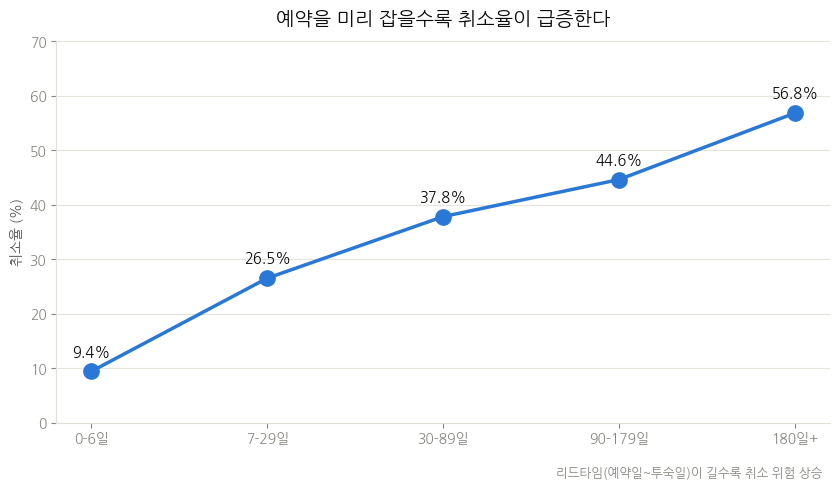

In [15]:
#① 리드타임별 취소율 곡선(첫 발견)
#시각화 스타일
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"
GOOD, WARN, CRIT = "#0ca30c", "#eda100", "#d03b3b"   # 저/중/고위험 색

def clean_ax(ax):
    for s in ["top","right"]: ax.spines[s].set_visible(False)
    for s in ["left","bottom"]: ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED); ax.set_axisbelow(True)
    ax.grid(axis="y", color=GRID, lw=0.8, alpha=0.9)

# 차트 1: 리드타임별 취소율
d = con.execute("""
    SELECT CASE WHEN lead_time<7 THEN '0-6일' WHEN lead_time<30 THEN '7-29일'
                WHEN lead_time<90 THEN '30-89일' WHEN lead_time<180 THEN '90-179일'
                ELSE '180일+' END AS 리드타임,
           ROUND(AVG(is_canceled)*100,1) AS 취소율, MIN(lead_time) AS ord
    FROM bookings GROUP BY 1 ORDER BY ord
""").df()

fig, ax = plt.subplots(figsize=(8.5,5)); clean_ax(ax)
ax.plot(d["리드타임"], d["취소율"], marker="o", ms=11, lw=2.5, color=BLUE, zorder=3)
for x,y in zip(d["리드타임"], d["취소율"]):
    ax.annotate(f"{y}%", (x,y), textcoords="offset points", xytext=(0,11),
                ha="center", fontsize=10.5, fontweight="bold", color=INK)
ax.set_ylim(0,70); ax.set_ylabel("취소율 (%)", color=INK2)
ax.set_title("예약을 미리 잡을수록 취소율이 급증한다", color=INK, fontsize=14, fontweight="bold", pad=12)
ax.text(0.99,-0.14,"리드타임(예약일~투숙일)이 길수록 취소 위험 상승", transform=ax.transAxes,
        ha="right", color=MUTED, fontsize=9)
plt.tight_layout()
plt.savefig("fig1_leadtime.png", dpi=150, bbox_inches="tight")   # Colab 파일에 저장
plt.show()

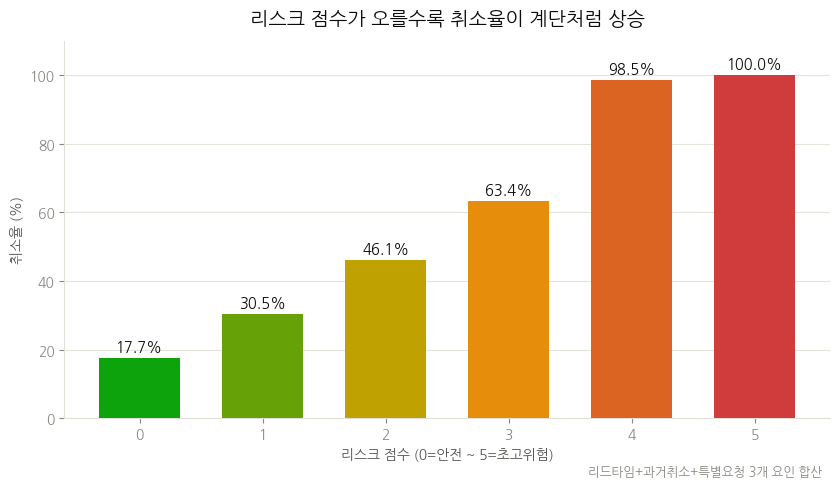

In [16]:
#② 리스크 점수별 취소율 계단(점수 검증)
import matplotlib.colors as mcolors
d2 = con.execute("""
    WITH scored AS (
        SELECT is_canceled,
              (CASE WHEN lead_time>=180 THEN 2 WHEN lead_time>=90 THEN 1 ELSE 0 END)
            + (CASE WHEN previous_cancellations>0 THEN 2 ELSE 0 END)
            + (CASE WHEN total_of_special_requests=0 THEN 1 ELSE 0 END) AS risk_score
        FROM bookings)
    SELECT risk_score, ROUND(AVG(is_canceled)*100,1) AS 취소율
    FROM scored GROUP BY 1 ORDER BY risk_score
""").df()

cmap = mcolors.LinearSegmentedColormap.from_list("risk", [GOOD, WARN, CRIT])
colors = [cmap(s/5) for s in d2["risk_score"]]
fig, ax = plt.subplots(figsize=(8.5,5)); clean_ax(ax)
ax.bar(d2["risk_score"].astype(str), d2["취소율"], color=colors, width=0.66, zorder=3)
for x,y in enumerate(d2["취소율"]):
    ax.annotate(f"{y}%",(x,y),xytext=(0,5),textcoords="offset points",ha="center",fontsize=10.5,fontweight="bold",color=INK)
ax.set_ylim(0,110); ax.set_xlabel("리스크 점수 (0=안전 ~ 5=초고위험)", color=INK2); ax.set_ylabel("취소율 (%)", color=INK2)
ax.set_title("리스크 점수가 오를수록 취소율이 계단처럼 상승", color=INK, fontsize=14, fontweight="bold", pad=12)
ax.text(0.99,-0.15,"리드타임+과거취소+특별요청 3개 요인 합산", transform=ax.transAxes, ha="right", color=MUTED, fontsize=9)
plt.tight_layout(); plt.savefig("fig2_riskscore.png", dpi=150, bbox_inches="tight"); plt.show()

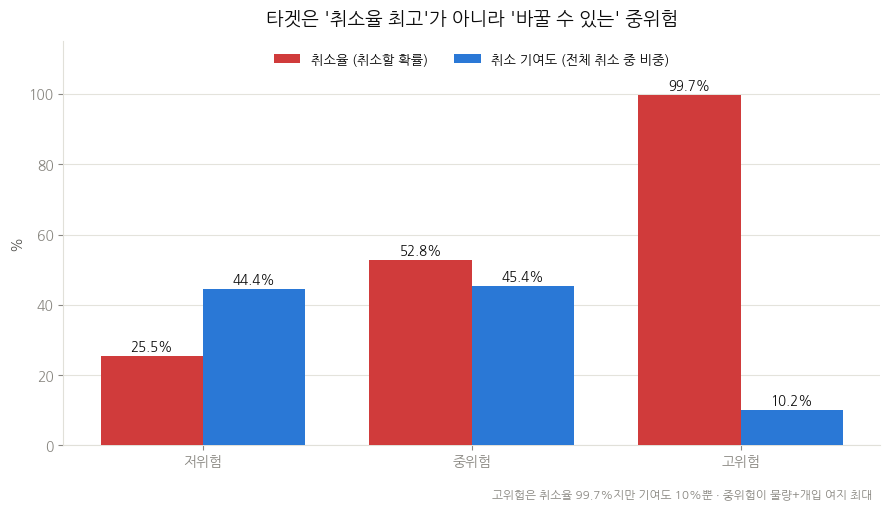

In [17]:
#③ 위험등급별 물량 vs 취소기여도(핵심 타겟팅 인사이트)
import numpy as np
d3 = con.execute("""
    WITH scored AS (
        SELECT is_canceled,
              (CASE WHEN lead_time>=180 THEN 2 WHEN lead_time>=90 THEN 1 ELSE 0 END)
            + (CASE WHEN previous_cancellations>0 THEN 2 ELSE 0 END)
            + (CASE WHEN total_of_special_requests=0 THEN 1 ELSE 0 END) AS risk_score
        FROM bookings),
    tiered AS (SELECT *, CASE WHEN risk_score<=1 THEN '저위험' WHEN risk_score<=3 THEN '중위험' ELSE '고위험' END AS 등급 FROM scored)
    SELECT 등급, ROUND(AVG(is_canceled)*100,1) AS 취소율,
           ROUND(100.0*SUM(is_canceled)/SUM(SUM(is_canceled)) OVER (),1) AS 취소기여도, MIN(risk_score) AS ord
    FROM tiered GROUP BY 1 ORDER BY ord
""").df()

x = np.arange(len(d3)); w = 0.38
fig, ax = plt.subplots(figsize=(9,5.2)); clean_ax(ax)
b1 = ax.bar(x-w/2, d3["취소율"], w, label="취소율 (취소할 확률)", color=CRIT, zorder=3)
b2 = ax.bar(x+w/2, d3["취소기여도"], w, label="취소 기여도 (전체 취소 중 비중)", color=BLUE, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(d3["등급"])
for bars in [b1,b2]:
    for bar in bars:
        h=bar.get_height(); ax.annotate(f"{h}%",(bar.get_x()+bar.get_width()/2,h),xytext=(0,4),
            textcoords="offset points",ha="center",fontsize=9.5,fontweight="bold",color=INK)
ax.set_ylim(0,115); ax.set_ylabel("%", color=INK2)
ax.legend(frameon=False, fontsize=9.5, loc="upper center", ncol=2)
ax.set_title("타겟은 '취소율 최고'가 아니라 '바꿀 수 있는' 중위험", color=INK, fontsize=13.5, fontweight="bold", pad=12)
ax.text(0.99,-0.13,"고위험은 취소율 99.7%지만 기여도 10%뿐 · 중위험이 물량+개입 여지 최대", transform=ax.transAxes, ha="right", color=MUTED, fontsize=8.5)
plt.tight_layout(); plt.savefig("fig3_targeting.png", dpi=150, bbox_inches="tight"); plt.show()